# 05 — PCA From Scratch, Applied to the Iris Dataset

This notebook ties everything together: vectors, matrices, covariance,
and eigen-decomposition combine into **Principal Component Analysis**
(`src/pca.py`), applied to a real dataset and compared against
`sklearn.decomposition.PCA`.

## The idea

1. Center the data.
2. Compute the covariance matrix — how features vary together.
3. Find its eigenvectors — the directions of maximum variance.
4. Project the data onto the top-k eigenvectors (principal components).

The result: a lower-dimensional representation of the data that preserves
as much variance (information) as possible.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
np.set_printoptions(precision=4, suppress=True)

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## Load the dataset

The Iris dataset: 150 flowers, 4 measured features, 3 species.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("X shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

X shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## Step 1 & 2 — Center the data, compute the covariance matrix

The covariance matrix captures how each pair of features varies together.
Its diagonal holds each feature's variance; off-diagonal entries capture
correlations between features.

In [3]:
from matrix_operations import covariance_matrix

cov = covariance_matrix(X)
print("Covariance matrix:\n", cov)

Covariance matrix:
 [[ 0.6857 -0.0424  1.2743  0.5163]
 [-0.0424  0.19   -0.3297 -0.1216]
 [ 1.2743 -0.3297  3.1163  1.2956]
 [ 0.5163 -0.1216  1.2956  0.581 ]]


## Step 3 — Eigen-decomposition of the covariance matrix

The eigenvector with the largest eigenvalue is the direction along which
the data varies the most — the **first principal component**.

In [4]:
from eigen import eigen_decomposition

eigenvalues, eigenvectors = eigen_decomposition(cov)
explained_variance_ratio = eigenvalues / eigenvalues.sum()

print("Eigenvalues:", eigenvalues)
print("Explained variance ratio:", explained_variance_ratio)

Eigenvalues: [4.2282 0.2427 0.0782 0.0238]
Explained variance ratio: [0.9246 0.0531 0.0171 0.0052]


## Step 4 — Project onto the top 2 principal components

In [5]:
from pca import PCA

my_pca = PCA(n_components=2)
X_projected = my_pca.fit_transform(X)

print("Projected shape:", X_projected.shape)
print("Explained variance ratio (top 2):", my_pca.explained_variance_ratio_)
print("Total variance retained:", my_pca.explained_variance_ratio_.sum())

Projected shape: (150, 2)
Explained variance ratio (top 2): [0.9246 0.0531]
Total variance retained: 0.9776852063187947


## Visualizing the 2D projection

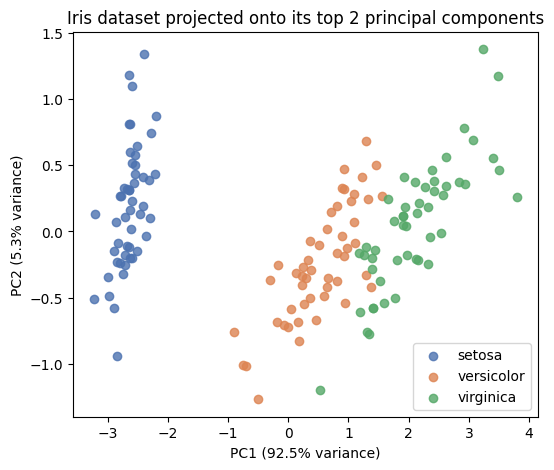

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for class_idx, class_name in enumerate(target_names):
    mask = y == class_idx
    ax.scatter(X_projected[mask, 0], X_projected[mask, 1],
               label=class_name, color=colors[class_idx], alpha=0.8)

ax.set_xlabel(f"PC1 ({my_pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({my_pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Iris dataset projected onto its top 2 principal components")
ax.legend()
plt.show()

## Comparison with scikit-learn

The whole point of building this from scratch: confirm it actually
matches a trusted, production implementation.

In [7]:
from sklearn.decomposition import PCA as SklearnPCA

sk_pca = SklearnPCA(n_components=2)
X_sklearn = sk_pca.fit_transform(X)

print("Explained variance ratio (mine)   :", my_pca.explained_variance_ratio_)
print("Explained variance ratio (sklearn):", sk_pca.explained_variance_ratio_)

# Principal component sign is arbitrary between implementations,
# so compare magnitudes rather than raw values.
max_abs_diff = np.max(np.abs(np.abs(X_projected) - np.abs(X_sklearn)))
print("\nMax absolute difference in projected coordinates:", max_abs_diff)

Explained variance ratio (mine)   : [0.9246 0.0531]
Explained variance ratio (sklearn): [0.9246 0.0531]

Max absolute difference in projected coordinates: 1.8011107882909272e-10


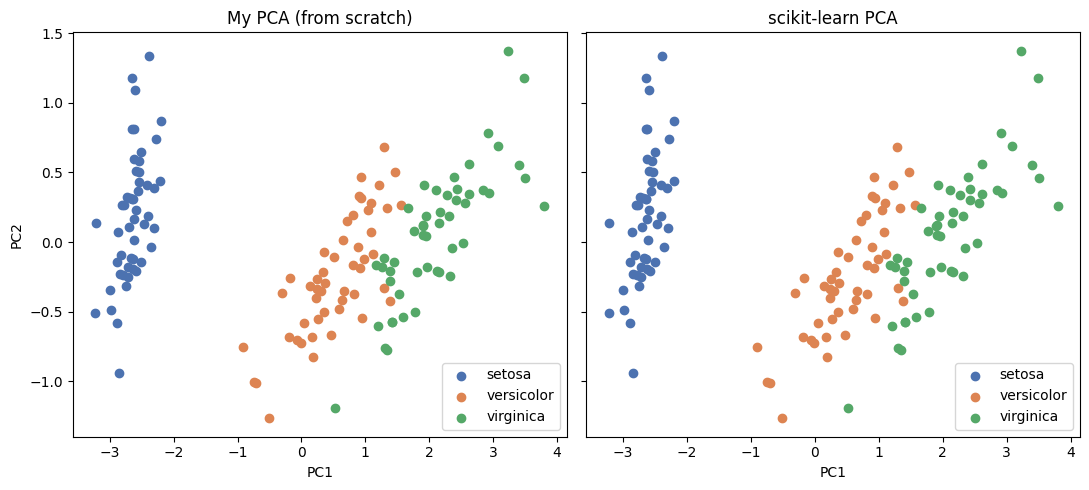

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for class_idx, class_name in enumerate(target_names):
    mask = y == class_idx
    axes[0].scatter(X_projected[mask, 0], X_projected[mask, 1], label=class_name, color=colors[class_idx])
    axes[1].scatter(X_sklearn[mask, 0], X_sklearn[mask, 1], label=class_name, color=colors[class_idx])

axes[0].set_title("My PCA (from scratch)")
axes[1].set_title("scikit-learn PCA")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.legend()
axes[0].set_ylabel("PC2")
plt.tight_layout()
plt.show()

## Conclusion

The from-scratch implementation matches scikit-learn's PCA on both the
explained variance ratio and the projected coordinates (up to an
arbitrary sign flip per component, which is expected — eigenvectors are
only defined up to sign).

Building this from the ground up — vectors, matrices, eigen-decomposition,
then PCA — made it clear that PCA is not a separate "ML algorithm" so much
as a direct, practical application of eigen-decomposition to a covariance
matrix.